In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r"C:\Users\avanindra Bose\OneDrive\Desktop\Real State Project\Cleaned Datasets\gurgaon_properties_cleaned_v2.csv")

In [5]:
df.head(5)

,property_type,society,sector,price,price_per_square_feet,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,rof aalayas,sector 102,0.45,6000.0,750.0,Built Up area: 750 (69.68 sq.m.),1,1,2,...,NaN,750.0,NaN,0,0,0,0,0,1,0
1,house,huda sector-56 gurgaon,sector 56,3.60,24845.0,1449.0,Plot area 161(134.62 sq.m.),5,5,3+,...,NaN,1449.0,NaN,0,0,0,0,1,1,47
2,flat,parsvnath green ville,sector 48,2.50,12820.0,1950.0,Carpet area: 1950 (181.16 sq.m.),4,5,3,...,NaN,NaN,1950.00,0,0,0,0,1,0,49
3,flat,emaar gurgaon greens,sector 102,1.35,8181.0,1650.0,Super Built up area 1650(153.29 sq.m.)Carpet a...,3,3,3,...,1650.0,NaN,1022.58,0,1,0,0,0,1,119
4,flat,raheja sampada,sector 92,0.65,4744.0,1370.0,Super Built up area 1370(127.28 sq.m.),3,2,3,...,1370.0,NaN,NaN,0,0,0,0,0,1,49


In [6]:
df.shape

(3801, 23)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3801 entries, 0 to 3800
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   property_type          3801 non-null   object 
 1   society                3800 non-null   object 
 2   sector                 3801 non-null   object 
 3   price                  3784 non-null   float64
 4   price_per_square_feet  3784 non-null   float64
 5   area                   3784 non-null   float64
 6   areaWithType           3801 non-null   object 
 7   bedRoom                3801 non-null   int64  
 8   bathroom               3801 non-null   int64  
 9   balcony                3801 non-null   object 
 10  floorNum               3782 non-null   float64
 11  facing                 2697 non-null   object 
 12  agePossession          3801 non-null   object 
 13  super_built_up_area    1914 non-null   float64
 14  built_up_area          1733 non-null   float64
 15  carp

In [8]:
df.duplicated().sum()

np.int64(126)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.duplicated().sum()

np.int64(0)

# Property Type 

In [11]:
df['property_type'].value_counts()

property_type
flat     2816
house     859
Name: count, dtype: int64

<Axes: xlabel='property_type', ylabel='count'>

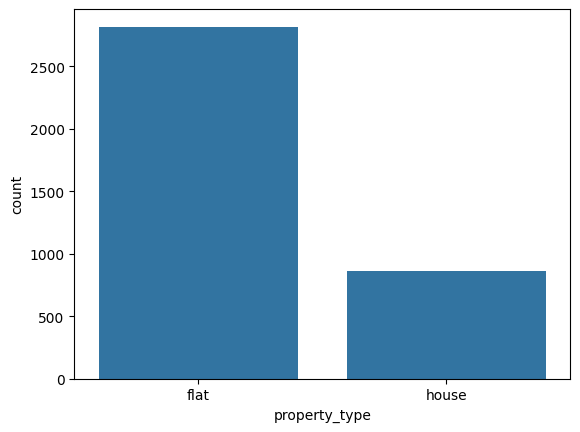

In [12]:
sns.countplot(data=df, x='property_type')

In [24]:
pct_flat = (df[df['property_type'] == "flat"].shape[0]/df['property_type'].shape[0])*100
pct_house = (df[df['property_type'] == "house"].shape[0]/df['property_type'].shape[0])*100

**Observations :** 

**1. We have 76% data of Flat and 24% data of house in our entire dataset.**

**2. There are no Missing Values.**

# Society 

In [25]:
df['society'].value_counts()

society
independent                             486
tulip violet                             75
ss the leaf                              73
dlf new town heights                     42
shapoorji pallonji joyville gurugram     42
                                       ... 
ashok vihar phase iii extension           1
jmd gardens                               1
the castle society                        1
millenium bajrang society                 1
ashiana apartment                         1
Name: count, Length: 674, dtype: int64

In [44]:
df['society'].value_counts().shape

(674,)

In [26]:
df['society'].isnull().sum()

np.int64(1)

In [33]:
df['society'].value_counts().sort_values(ascending=False).head(10)

society
independent                             486
tulip violet                             75
ss the leaf                              73
dlf new town heights                     42
shapoorji pallonji joyville gurugram     42
signature global park                    35
shree vardhman victoria                  34
smart world orchard                      32
emaar mgf emerald floors premier         32
dlf the ultima                           31
Name: count, dtype: int64

In [ ]:
df[df['society'] == "independent"].shape[0] / df['society'].shape[0] * 100

13.224489795918368

<Axes: xlabel='society'>

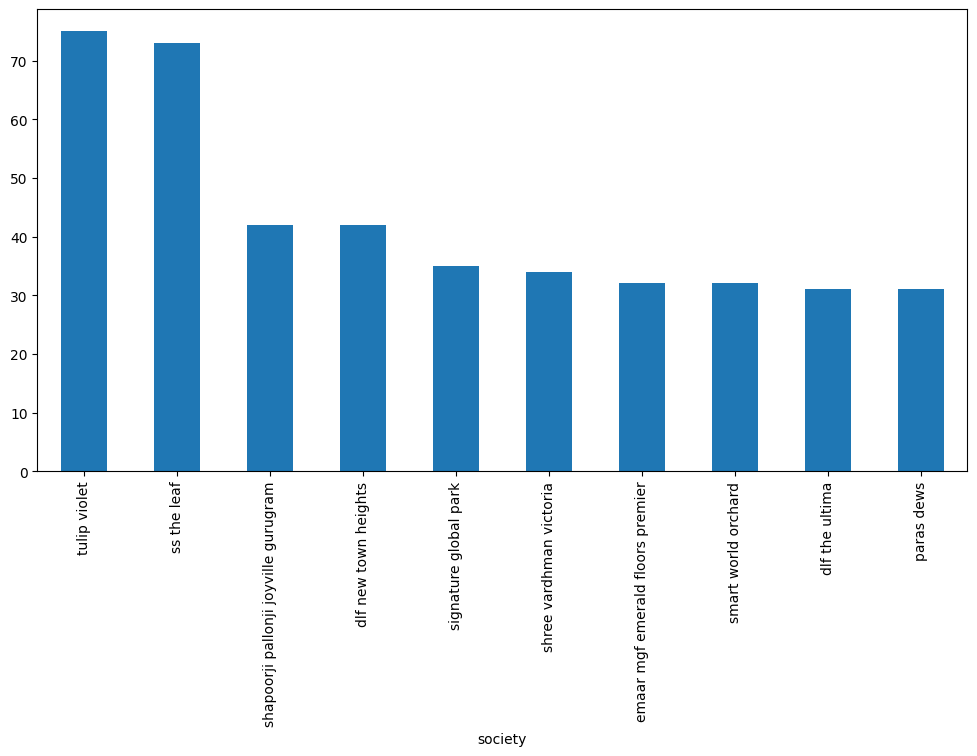

In [41]:
df[df['society'] != "independent"]['society'].value_counts().sort_values(ascending=False).head(10).plot(kind='bar', figsize=(12,6))

In [42]:
df[df['society'] != 'independent']['society'].value_counts(normalize=True).cumsum().head(75)

society
tulip violet                            0.023526
ss the leaf                             0.046424
shapoorji pallonji joyville gurugram    0.059598
dlf new town heights                    0.072773
signature global park                   0.083752
                                          ...   
puri emerald bay                        0.490590
umang monsoon breeze                    0.494668
indiabulls enigma                       0.498745
central park flower valley              0.502509
ireo the corridors                      0.506274
Name: proportion, Length: 75, dtype: float64

In [45]:
society_counts = df['society'].value_counts()

# Frequency distribution for societies
frequency_bins = {
    "Very High (>100)": (society_counts > 100).sum(),
    "High (50-100)": ((society_counts >= 50) & (society_counts <= 100)).sum(),
    "Average (10-49)": ((society_counts >= 10) & (society_counts < 50)).sum(),
    "Low (2-9)": ((society_counts > 1) & (society_counts < 10)).sum(),
    "Very Low (1)": (society_counts == 1).sum()
}
frequency_bins

{'Very High (>100)': np.int64(1),
 'High (50-100)': np.int64(2),
 'Average (10-49)': np.int64(92),
 'Low (2-9)': np.int64(273),
 'Very Low (1)': np.int64(306)}

**Observations :**

**1. Around 13% properties comes under independent tag.**

**2. There are 673 societies.**

**3. The top 75 societies have 50 percent of the preperties and the rest 50 percent of the properties come under the remaining 598 societies**

**4. Very High (>100): Only 1 society has more than 100 listings.**

**5. High (50-100): 2 societies have between 50 to 100 listings.**

**6. Average (10-49): 92 societies fall in this range with 10 to 49 listings each.**

**7. Low (2-9): 273 societies have between 2 to 9 listings.**

**8. Very Low (1): A significant number, 308 societies, have only 1 listing.**

**9. 1 missing value**

# Sector

In [46]:
df['sector'].value_counts()

sector
sohna road    154
sector 85     108
sector 102    107
sector 92     100
sector 69      93
             ... 
sector 17a      3
sector 27       3
sector 17b      3
sector 73       3
sector 88b      3
Name: count, Length: 112, dtype: int64

In [47]:
df['sector'].value_counts().shape

(112,)

In [48]:
df['sector'].isnull().sum()

np.int64(0)

In [51]:
df['sector'].unique()

array(['sector 102', 'sector 56', 'sector 48', 'sector 92', 'sector 104',
       'sector 108', 'sector 6', 'sector 70', 'sector 113', 'sector 103',
       'sector 26', 'sector 54', 'manesar', 'sector 23', 'sector 49',
       'sector 99', 'sector 28', 'sector 37c', 'sector 70a', 'sector 57',
       'sector 2', 'sector 59', 'sector 12', 'sector 79', 'sohna road',
       'sector 83', 'sector 69', 'sector 62', 'sector 52', 'sector 3',
       'sector 33', 'sector 38', 'sector 85', 'sector 111', 'sector 84',
       'sector 41', 'sector 107', 'sector 65', 'sector 36', 'sector 50',
       'sector 90', 'sector 7', 'sector 77', 'sector 82', 'sector 71',
       'sector 67', 'sector 43', 'sector 4', 'sector 37d', 'sector 31',
       'sector 46', 'sector 99a', 'sector 68', 'sector 81', 'sector 51',
       'sector 66', 'sector 109', 'sector 61', 'sector 45', 'sector 63',
       'sector 86', 'sector 76', 'sector 60', 'sector 89', 'sector 1',
       'sector 58', 'sector 110', 'sector 91', 'sector 72',

<Axes: xlabel='sector'>

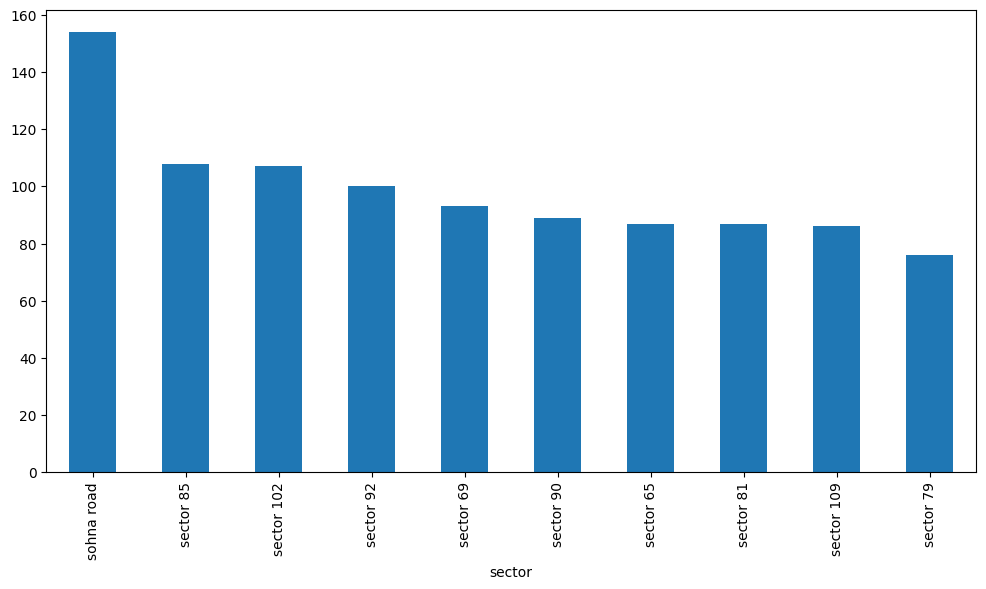

In [52]:
df['sector'].value_counts().head(10).plot(kind='bar', figsize=(12,6))

In [53]:
sector_counts = df['sector'].value_counts()

sector_frequency_bins = {
    "Very High (>100)": (sector_counts > 100).sum(),
    "High (50-100)": ((sector_counts >= 50) & (sector_counts <= 100)).sum(),
    "Average (10-49)": ((sector_counts >= 10) & (sector_counts < 50)).sum(),
    "Low (2-9)": ((sector_counts > 1) & (sector_counts < 10)).sum(),
    "Very Low (1)": (sector_counts == 1).sum()
}

sector_frequency_bins

{'Very High (>100)': np.int64(3),
 'High (50-100)': np.int64(25),
 'Average (10-49)': np.int64(62),
 'Low (2-9)': np.int64(22),
 'Very Low (1)': np.int64(0)}

**Observations :** 

**There are a total of 104 unique sectors in the dataset.**

**Frequency distribution of sectors:**

**1.Very High (>100): 3 sectors have more than 100 listings.**

**2.High (50-100): 25 sectors have between 50 to 100 listings.**

**3.Average (10-49): A majority, 60 sectors, fall in this range with 10 to 49 listings each.**

**4.Low (2-9): 16 sectors have between 2 to 9 listings.**

**5.Very Low (1): Interestingly, there is only 1 sector with only 1 listing.**